In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**FEATURE EXTRACTION**

In [ ]:
# ============================================================================
# FEATURE EXTRACTION
# Staleness-Aware Asynchronous Multi-Node Sensor Fusion
# Indoor Gait / Movement-Pattern Dataset (Direct / Pacing / Lapping / Random)
#

# ============================================================================





import os
import re
import math
import glob
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

# ---- Path to your dataset in Drive ----------------------------------------

DATASET_ROOT = "/content/drive/MyDrive/Staleness_Gait_Dataset"

# Where the extracted feature table (Step 7 output) will be saved.
OUTPUT_DIR = DATASET_ROOT
OUTPUT_CSV = os.path.join(OUTPUT_DIR, "step7_features.csv")

NODES = ["N1", "N2", "N3", "N4"]
SNAPSHOT_INTERVAL_MS = 200.0  # fusion cadence from the logger (Step 5/6)

# %% CELL 3 — Discover all subject/pattern CSV files
def discover_csv_files(root):
    """
    Recursively find every SxxxPattern.csv file, regardless of how deep
    the Subject_XXX folders are nested under `root`.
    """
    pattern = re.compile(r"^S(\d{3})_(Direct|Pacing|Lapping|Random)\.csv$", re.IGNORECASE)
    files = []
    for path in glob.glob(os.path.join(root, "**", "*.csv"), recursive=True):
        fname = os.path.basename(path)
        m = pattern.match(fname)
        if m:
            files.append({
                "path": path,
                "subject_id": m.group(1),
                "pattern": m.group(2).capitalize(),
            })
    return sorted(files, key=lambda r: (r["subject_id"], r["pattern"]))


csv_files = discover_csv_files(DATASET_ROOT)
print(f"Found {len(csv_files)} subject-pattern CSV files.")
print(f"Unique subjects: {sorted(set(f['subject_id'] for f in csv_files))}")
if len(csv_files) == 0:
    raise FileNotFoundError(
        f"No CSV files matched under {DATASET_ROOT}. "
        f"Check that Staleness_Gait_Dataset is uploaded to your Drive "
        f"and that filenames look like S001_Direct.csv."
    )

# %% CELL 4 — Low-level helpers

def parse_timestamp_to_ms(ts_series):
    """
    Convert 'HH:MM:SS.mmm' strings to elapsed milliseconds from the first
    sample in the file. Handles a possible midnight rollover.
    """
    t = pd.to_datetime(ts_series, format="%H:%M:%S.%f")
    ms = (t.dt.hour * 3600 + t.dt.minute * 60 + t.dt.second) * 1000 + t.dt.microsecond / 1000.0
    ms = ms.to_numpy(dtype=float)
    # fix midnight rollover (rare, but recordings could span it)
    diffs = np.diff(ms)
    rollover_idx = np.where(diffs < -1000)[0]
    for idx in rollover_idx:
        ms[idx + 1:] += 24 * 3600 * 1000
    return ms - ms[0]


def shannon_entropy(counts_dict):
    """Normalized Shannon entropy (0-1) of a distribution of counts."""
    total = sum(counts_dict.values())
    if total == 0:
        return 0.0
    probs = [c / total for c in counts_dict.values() if c > 0]
    if len(probs) <= 1:
        return 0.0
    h = -sum(p * math.log2(p) for p in probs)
    h_max = math.log2(len(probs))
    return h / h_max if h_max > 0 else 0.0


def get_active_node_series(df):
    """
    For each snapshot row, pick the node that is MOTION_DETECTED with the
    highest staleness-aware fusion weight. Returns a list of 'N1'..'N4' or
    None (no node active that snapshot).
    """
    active = []
    status_cols = {n: df[f"{n}_Status"].to_numpy() for n in NODES}
    weight_cols = {n: df[f"{n}_Weight"].to_numpy() for n in NODES}

    for i in range(len(df)):
        best_node, best_w = None, -1.0
        for n in NODES:
            if status_cols[n][i] == "MOTION_DETECTED":
                w = weight_cols[n][i]
                w = 0.0 if pd.isna(w) else w
                if w > best_w:
                    best_w, best_node = w, n
        active.append(best_node)
    return active


def collapse_runs(active_seq):
    """
    Collapse a raw per-snapshot active-node sequence into runs of
    (node, run_length_in_snapshots), skipping None (idle) snapshots.
    e.g. [N1,N1,None,N1,N2,N2,N3] -> [(N1,3), (N2,2), (N3,1)]
    """
    runs = []
    current_node, current_len = None, 0
    for node in active_seq:
        if node is None:
            continue
        if node == current_node:
            current_len += 1
        else:
            if current_node is not None:
                runs.append((current_node, current_len))
            current_node, current_len = node, 1
    if current_node is not None:
        runs.append((current_node, current_len))
    return runs


# %% Per-file feature extraction

def extract_features(df, subject_id, pattern, source_file):
    feat = {"Subject_ID": subject_id, "Pattern": pattern, "Source_File": source_file}

    n_rows = len(df)
    elapsed_ms = parse_timestamp_to_ms(df["Timestamp"])
    duration_sec = elapsed_ms[-1] / 1000.0 if n_rows > 0 else 0.0
    feat["Num_Snapshots"] = n_rows
    feat["Duration_Sec"] = round(duration_sec, 3)

    # ---------------- A. Transition sequence features -----------------
    active_seq = get_active_node_series(df)
    active_counts = Counter([a for a in active_seq if a is not None])
    total_active_frames = sum(active_counts.values())

    for n in NODES:
        cnt = active_counts.get(n, 0)
        feat[f"{n}_Activation_Count"] = cnt
        feat[f"{n}_Activation_Ratio"] = round(cnt / n_rows, 4) if n_rows else 0.0

    runs = collapse_runs(active_seq)

    # dwell time (ms) per node = run_length * snapshot interval
    dwell_by_node = defaultdict(list)
    for node, run_len in runs:
        dwell_by_node[node].append(run_len * SNAPSHOT_INTERVAL_MS)

    all_dwells = [d for v in dwell_by_node.values() for d in v]
    feat["Mean_Dwell_Time_MS"] = round(float(np.mean(all_dwells)), 3) if all_dwells else 0.0
    feat["Std_Dwell_Time_MS"] = round(float(np.std(all_dwells)), 3) if all_dwells else 0.0
    for n in NODES:
        vals = dwell_by_node.get(n, [])
        feat[f"{n}_Mean_Dwell_MS"] = round(float(np.mean(vals)), 3) if vals else 0.0

    # node-to-node transitions (ordered pairs, e.g. N1->N2)
    transition_counts = Counter()
    for (node_a, _), (node_b, _) in zip(runs, runs[1:]):
        transition_counts[(node_a, node_b)] += 1

    for a in NODES:
        for b in NODES:
            if a != b:
                feat[f"Trans_{a}_to_{b}"] = transition_counts.get((a, b), 0)

    # bidirectional (unordered pair) transition counts
    pairs = [("N1", "N2"), ("N1", "N3"), ("N1", "N4"),
             ("N2", "N3"), ("N2", "N4"), ("N3", "N4")]
    for a, b in pairs:
        bidir = transition_counts.get((a, b), 0) + transition_counts.get((b, a), 0)
        feat[f"Bidir_{a}_{b}"] = bidir

    feat["Total_Transitions"] = sum(transition_counts.values())
    feat["Transition_Entropy"] = round(shannon_entropy(transition_counts), 4)
    feat["Position_Entropy"] = round(shannon_entropy(active_counts), 4)

    # ---------------- B. Distance & timing features ---------------------
    for n in NODES:
        dist = df[f"{n}_Distance_CM"].to_numpy(dtype=float)
        valid = dist[~np.isnan(dist)]
        feat[f"{n}_Mean_Distance_CM"] = round(float(np.mean(valid)), 3) if len(valid) else np.nan
        feat[f"{n}_Std_Distance_CM"] = round(float(np.std(valid)), 3) if len(valid) else np.nan

        # speed proxy: |delta distance| / delta t between consecutive VALID
        # readings of this node (cm/s)
        valid_idx = np.where(~np.isnan(dist))[0]
        if len(valid_idx) >= 2:
            d_vals = dist[valid_idx]
            t_vals = elapsed_ms[valid_idx]
            dt = np.diff(t_vals) / 1000.0  # seconds
            dd = np.abs(np.diff(d_vals))
            with np.errstate(divide="ignore", invalid="ignore"):
                speeds = np.where(dt > 0, dd / dt, np.nan)
            speeds = speeds[~np.isnan(speeds)]
            feat[f"{n}_Speed_Proxy_CMPS"] = round(float(np.mean(speeds)), 3) if len(speeds) else 0.0
        else:
            feat[f"{n}_Speed_Proxy_CMPS"] = 0.0

    fused_dist = df["Fused_Distance_CM"].to_numpy(dtype=float)
    fused_valid = fused_dist[~np.isnan(fused_dist)]
    feat["Fused_Mean_Distance_CM"] = round(float(np.mean(fused_valid)), 3) if len(fused_valid) else np.nan
    feat["Fused_Std_Distance_CM"] = round(float(np.std(fused_valid)), 3) if len(fused_valid) else np.nan

    # inter-event intervals: gaps between snapshots where ANY node is active
    active_any_idx = np.where(df["Contributing_Nodes"].to_numpy(dtype=float) > 0)[0]
    if len(active_any_idx) >= 2:
        event_times = elapsed_ms[active_any_idx]
        intervals = np.diff(event_times)
        feat["Mean_InterEvent_MS"] = round(float(np.mean(intervals)), 3)
        feat["Std_InterEvent_MS"] = round(float(np.std(intervals)), 3)
    else:
        feat["Mean_InterEvent_MS"] = 0.0
        feat["Std_InterEvent_MS"] = 0.0

    # overall movement-speed proxy from the fused distance track
    if len(fused_valid) >= 2:
        fused_valid_idx = np.where(~np.isnan(fused_dist))[0]
        t_vals = elapsed_ms[fused_valid_idx]
        d_vals = fused_dist[fused_valid_idx]
        dt = np.diff(t_vals) / 1000.0
        dd = np.abs(np.diff(d_vals))
        with np.errstate(divide="ignore", invalid="ignore"):
            speeds = np.where(dt > 0, dd / dt, np.nan)
        speeds = speeds[~np.isnan(speeds)]
        feat["Fused_Speed_Proxy_CMPS"] = round(float(np.mean(speeds)), 3) if len(speeds) else 0.0
    else:
        feat["Fused_Speed_Proxy_CMPS"] = 0.0

    # ---------------- Staleness statistics (unique to this pipeline) ----
    mean_stale = df["Mean_Staleness_MS"].to_numpy(dtype=float)
    max_stale = df["Max_Staleness_MS"].to_numpy(dtype=float)
    feat["Avg_Mean_Staleness_MS"] = round(float(np.nanmean(mean_stale)), 3) if n_rows else 0.0
    feat["Avg_Max_Staleness_MS"] = round(float(np.nanmean(max_stale)), 3) if n_rows else 0.0

    fresh_ratios = []
    for n in NODES:
        fresh_ratios.append(df[f"{n}_Fresh"].mean())
    feat["Mean_Fresh_Ratio"] = round(float(np.mean(fresh_ratios)), 4)

    feat["Mean_Total_Fusion_Weight"] = round(float(df["Total_Fusion_Weight"].mean()), 4)
    feat["Mean_Contributing_Nodes"] = round(float(df["Contributing_Nodes"].mean()), 4)

    return feat


#  Run extraction over the whole dataset (25 subjects x 4 patterns)
all_features = []
failed = []

for entry in csv_files:
    try:
        df = pd.read_csv(entry["path"])
        feats = extract_features(df, entry["subject_id"], entry["pattern"], entry["path"])
        all_features.append(feats)
    except Exception as e:
        failed.append((entry["path"], str(e)))

print(f"Successfully processed: {len(all_features)} / {len(csv_files)} files")
if failed:
    print("Failed files:")
    for path, err in failed:
        print(f"  {path}: {err}")

feature_df = pd.DataFrame(all_features)

# Order columns: identifiers first, then everything else alphabetically-ish
id_cols = ["Subject_ID", "Pattern", "Source_File"]
other_cols = [c for c in feature_df.columns if c not in id_cols]
feature_df = feature_df[id_cols + other_cols]

print(f"\nFeature table shape: {feature_df.shape}")
print(f"Class balance:\n{feature_df['Pattern'].value_counts()}")
feature_df.head()

# %% CELL 7 — Save feature table (Step 7 output -> feeds Step 8 classification)
os.makedirs(OUTPUT_DIR, exist_ok=True)
feature_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved feature dataset to: {OUTPUT_CSV}")

# Also keep a local copy in the Colab session for quick reuse
feature_df.to_csv("/content/step7_features.csv", index=False)
print("Local copy saved to /content/step7_features.csv")

# %% CELL 8 — Sanity checks
print("\nMissing values per column (top 10):")
print(feature_df.isna().sum().sort_values(ascending=False).head(10))

print("\nSubjects covered:", feature_df["Subject_ID"].nunique())
print("Rows per pattern:")
print(feature_df.groupby("Pattern").size())

print("\nExample feature row:")
print(feature_df.iloc[0])

Found 100 subject-pattern CSV files.
Unique subjects: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025']
Successfully processed: 100 / 100 files

Feature table shape: (100, 62)
Class balance:
Pattern
Direct     25
Lapping    25
Pacing     25
Random     25
Name: count, dtype: int64
Saved feature dataset to: /content/drive/MyDrive/Staleness_Gait_Dataset/step7_features.csv
Local copy saved to /content/step7_features.csv

Missing values per column (top 10):
Subject_ID             0
Pattern                0
Source_File            0
Num_Snapshots          0
Duration_Sec           0
N1_Activation_Count    0
N1_Activation_Ratio    0
N2_Activation_Count    0
N2_Activation_Ratio    0
N3_Activation_Count    0
dtype: int64

Subjects covered: 25
Rows per pattern:
Pattern
Direct     25
Lapping    25
Pacing     25
Random     25
dtype: int64

Example feature row:
Subject_ID     

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 869.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 153.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 106.4 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Loaded feature table: (100, 62)
Pattern
Direct     25
Lapping    25
Pacing     25
Random     25
Name: count, dtype: int64
Unique subjects: 25
Classes (4): ['Direct', 'Lapping', 'Pacing', 'Random']
Feature count: 59
Train: 80 rows (20 subjects)
Test : 20 rows (5 subjects)
RANDOM FOREST — subject-wise 5-fold CV
  Fold 1: acc=0.900  macro-F1=0.899
  Fold 2: acc=0.750  macro-F1=0.751
  Fold 3: acc=0.650  macro-F1=0.628
  Fold 4: acc=0.850  macro-F1=0.847
  Fold 5: acc=0.900  macro-F1=0.900
RF  mean acc: 0.810 +/- 0.097 | mean macro-F1: 0.805

Held-out test report (Random Forest):
              precision    recall  f1-score   support

      Direct       0.57      0.80      0.67         5
     Lapping       1.00      0.60      0.75         5
      Pacing       1.00      0.60      0.75         5
      Random       0.43      0.60      0.50         5

    accuracy                           0.65        20
   macro avg       0.75      0.65      0.67        20
weighted avg       0.75      0.65    

  Fold 5: acc=0.700  macro-F1=0.684
CNN mean acc: 0.610 +/- 0.097 | mean macro-F1: 0.593



Held-out test report (1D-CNN):
              precision    recall  f1-score   support

      Direct       0.36      0.80      0.50         5
     Lapping       0.50      0.20      0.29         5
      Pacing       0.75      0.60      0.67         5
      Random       0.33      0.20      0.25         5

    accuracy                           0.45        20
   macro avg       0.49      0.45      0.43        20
weighted avg       0.49      0.45      0.43        20

LSTM — subject-wise 5-fold CV
  Fold 1: acc=0.650  macro-F1=0.644
  Fold 2: acc=0.650  macro-F1=0.654
  Fold 3: acc=0.350  macro-F1=0.356
  Fold 4: acc=0.600  macro-F1=0.585
  Fold 5: acc=0.700  macro-F1=0.683
LSTM mean acc: 0.590 +/- 0.124 | mean macro-F1: 0.584

Held-out test report (LSTM):
              precision    recall  f1-score   support

      Direct       0.50      0.60      0.55         5
     Lapping       1.00      1.00      1.00         5
      Pacing       1.00      0.60      0.75         5
      Random       0.5

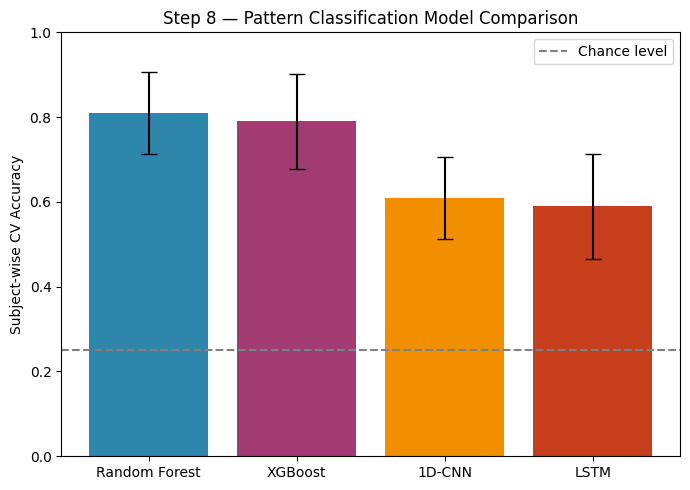


Best model by CV accuracy: Random Forest


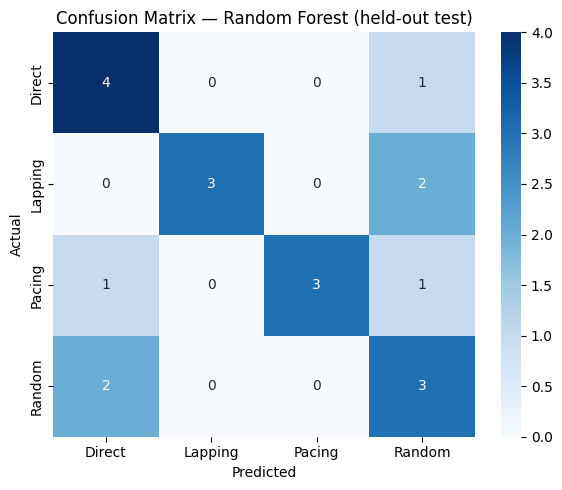

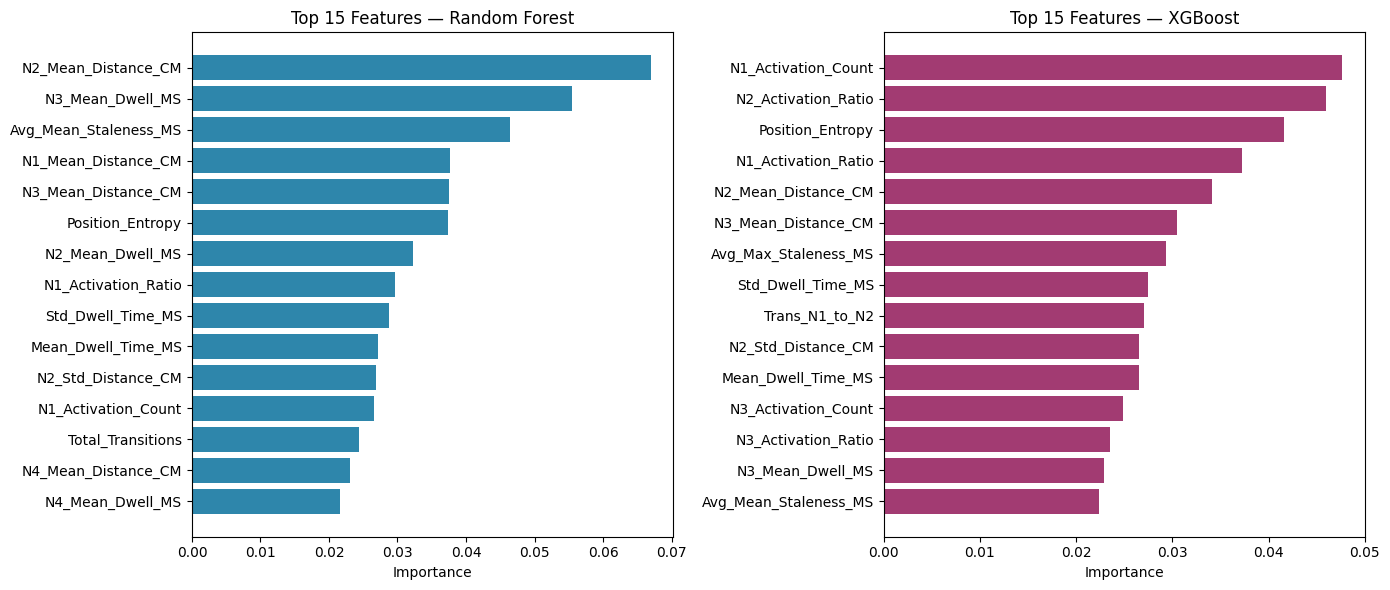


All models and results saved to: /content/drive/MyDrive/Staleness_Gait_Dataset/step8_models
Step 8 complete — outputs ready for Step 9 (Robustness Evaluation).


In [ ]:
# ============================================================================
# STEP 8 — PATTERN CLASSIFICATION
# Staleness-Aware Asynchronous Multi-Node Sensor Fusion
# Classes: Direct / Pacing / Lapping / Random
#
# Models: Random Forest, XGBoost, 1D-CNN, LSTM  (per architecture diagram)
# Evaluation: SUBJECT-WISE Stratified Group K-Fold — no subject ever appears
#          in both train and test, so accuracy reflects generalization to
#          UNSEEN people, not memorized per-person quirks.
# ============================================================================




!pip install xgboost -q
!pip install -q tensorflow


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

tf.random.set_seed(42)
np.random.seed(42)

# Load Step 7 features
DATASET_ROOT = "/content/drive/MyDrive/Staleness_Gait_Dataset"
FEATURES_CSV = os.path.join(DATASET_ROOT, "step7_features.csv")

df = pd.read_csv(FEATURES_CSV)
print(f"Loaded feature table: {df.shape}")
print(df["Pattern"].value_counts())
print(f"Unique subjects: {df['Subject_ID'].nunique()}")
assert df.isna().sum().sum() == 0, "Unexpected NaNs in feature table — check Step 7 output."

ID_COLS = ["Subject_ID", "Pattern", "Source_File"]
FEATURE_COLS = [c for c in df.columns if c not in ID_COLS]

X_raw = df[FEATURE_COLS].to_numpy(dtype=float)
groups = df["Subject_ID"].to_numpy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Pattern"])
CLASS_NAMES = list(label_encoder.classes_)
N_CLASSES = len(CLASS_NAMES)
print(f"Classes ({N_CLASSES}): {CLASS_NAMES}")
print(f"Feature count: {len(FEATURE_COLS)}")

#  Held-out test split (subject-wise, never mixes a subject
# across train/test) — used for the final classification report.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_raw, y, groups))

X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print(f"Train: {len(train_idx)} rows ({len(set(groups_train))} subjects)")
print(f"Test : {len(test_idx)} rows ({len(set(groups[test_idx]))} subjects)")
# sanity check: no subject leakage
assert set(groups[train_idx]).isdisjoint(set(groups[test_idx])), "Subject leakage detected!"

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

#  Subject-wise cross-validation helper (used to compare models)
def subject_wise_cv_score(build_and_fit_fn, X, y, groups, n_splits=5, is_dl=False):
    """
    Runs StratifiedGroupKFold so every fold's test subjects are unseen
    during training. Returns per-fold accuracy and macro-F1.
    """
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_acc, fold_f1 = [], []

    for fold, (tr, te) in enumerate(sgkf.split(X, y, groups)):
        scaler_fold = StandardScaler()
        Xtr = scaler_fold.fit_transform(X[tr])
        Xte = scaler_fold.transform(X[te])

        model = build_and_fit_fn(Xtr, y[tr])
        if is_dl:
            preds = np.argmax(model.predict(Xte, verbose=0), axis=1)
        else:
            preds = model.predict(Xte)

        acc = accuracy_score(y[te], preds)
        _, _, f1, _ = precision_recall_fscore_support(
            y[te], preds, average="macro", zero_division=0
        )
        fold_acc.append(acc)
        fold_f1.append(f1)
        print(f"  Fold {fold+1}: acc={acc:.3f}  macro-F1={f1:.3f}")

    return np.array(fold_acc), np.array(fold_f1)


#  Model 1: Random Forest
print("=" * 60)
print("RANDOM FOREST — subject-wise 5-fold CV")
print("=" * 60)

def build_rf(Xtr, ytr):
    m = RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    )
    m.fit(Xtr, ytr)
    return m

rf_acc, rf_f1 = subject_wise_cv_score(build_rf, X_raw, y, groups)
print(f"RF  mean acc: {rf_acc.mean():.3f} +/- {rf_acc.std():.3f} | mean macro-F1: {rf_f1.mean():.3f}")

# Final model on the held-out split, for the detailed report
rf_final = build_rf(X_train, y_train)
rf_test_preds = rf_final.predict(X_test)
print("\nHeld-out test report (Random Forest):")
print(classification_report(y_test, rf_test_preds, target_names=CLASS_NAMES, zero_division=0))

#  Model 2: XGBoost
print("=" * 60)
print("XGBOOST — subject-wise 5-fold CV")
print("=" * 60)

def build_xgb(Xtr, ytr):
    m = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", num_class=N_CLASSES,
        eval_metric="mlogloss", random_state=42, n_jobs=-1
    )
    m.fit(Xtr, ytr)
    return m

xgb_acc, xgb_f1 = subject_wise_cv_score(build_xgb, X_raw, y, groups)
print(f"XGB mean acc: {xgb_acc.mean():.3f} +/- {xgb_acc.std():.3f} | mean macro-F1: {xgb_f1.mean():.3f}")

xgb_final = build_xgb(X_train, y_train)
xgb_test_preds = xgb_final.predict(X_test)
print("\nHeld-out test report (XGBoost):")
print(classification_report(y_test, xgb_test_preds, target_names=CLASS_NAMES, zero_division=0))

#  Model 3: 1D-CNN
# The engineered feature vector is treated as a 1-D signal
# (feature_index acts as the spatial/sequence axis for the conv filters).
print("=" * 60)
print("1D-CNN — subject-wise 5-fold CV")
print("=" * 60)

N_FEATURES = X_raw.shape[1]

def build_cnn_model():
    model = models.Sequential([
        layers.Input(shape=(N_FEATURES, 1)),
        layers.Conv1D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(N_CLASSES, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_cnn(Xtr, ytr):
    Xtr_r = Xtr.reshape(-1, N_FEATURES, 1)
    m = build_cnn_model()
    es = callbacks.EarlyStopping(monitor="loss", patience=15, restore_best_weights=True)
    m.fit(Xtr_r, ytr, epochs=150, batch_size=8, verbose=0, callbacks=[es])
    return m

cnn_acc, cnn_f1 = subject_wise_cv_score(build_cnn, X_raw, y, groups, is_dl=True)
print(f"CNN mean acc: {cnn_acc.mean():.3f} +/- {cnn_acc.std():.3f} | mean macro-F1: {cnn_f1.mean():.3f}")

cnn_final = build_cnn(X_train, y_train)
cnn_test_preds = np.argmax(cnn_final.predict(X_test.reshape(-1, N_FEATURES, 1), verbose=0), axis=1)
print("\nHeld-out test report (1D-CNN):")
print(classification_report(y_test, cnn_test_preds, target_names=CLASS_NAMES, zero_division=0))

#  Model 4: LSTM
print("=" * 60)
print("LSTM — subject-wise 5-fold CV")
print("=" * 60)

def build_lstm_model():
    model = models.Sequential([
        layers.Input(shape=(N_FEATURES, 1)),
        layers.LSTM(48, return_sequences=True),
        layers.Dropout(0.3),
        layers.LSTM(24),
        layers.Dropout(0.3),
        layers.Dense(24, activation="relu"),
        layers.Dense(N_CLASSES, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_lstm(Xtr, ytr):
    Xtr_r = Xtr.reshape(-1, N_FEATURES, 1)
    m = build_lstm_model()
    es = callbacks.EarlyStopping(monitor="loss", patience=15, restore_best_weights=True)
    m.fit(Xtr_r, ytr, epochs=150, batch_size=8, verbose=0, callbacks=[es])
    return m

lstm_acc, lstm_f1 = subject_wise_cv_score(build_lstm, X_raw, y, groups, is_dl=True)
print(f"LSTM mean acc: {lstm_acc.mean():.3f} +/- {lstm_acc.std():.3f} | mean macro-F1: {lstm_f1.mean():.3f}")

lstm_final = build_lstm(X_train, y_train)
lstm_test_preds = np.argmax(lstm_final.predict(X_test.reshape(-1, N_FEATURES, 1), verbose=0), axis=1)
print("\nHeld-out test report (LSTM):")
print(classification_report(y_test, lstm_test_preds, target_names=CLASS_NAMES, zero_division=0))

#  Model comparison summary
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "1D-CNN", "LSTM"],
    "CV_Mean_Accuracy": [rf_acc.mean(), xgb_acc.mean(), cnn_acc.mean(), lstm_acc.mean()],
    "CV_Std_Accuracy": [rf_acc.std(), xgb_acc.std(), cnn_acc.std(), lstm_acc.std()],
    "CV_Mean_MacroF1": [rf_f1.mean(), xgb_f1.mean(), cnn_f1.mean(), lstm_f1.mean()],
})
print("\n" + "=" * 60)
print("MODEL COMPARISON (subject-wise 5-fold CV)")
print("=" * 60)
print(results.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(results["Model"], results["CV_Mean_Accuracy"], yerr=results["CV_Std_Accuracy"],
       capsize=6, color=["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"])
ax.axhline(1 / N_CLASSES, color="gray", linestyle="--", label="Chance level")
ax.set_ylabel("Subject-wise CV Accuracy")
ax.set_title("Step 8 — Pattern Classification Model Comparison")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATASET_ROOT, "step8_model_comparison.png"), dpi=150)
plt.show()

#  Confusion matrix for the best CV model
best_model_name = results.loc[results["CV_Mean_Accuracy"].idxmax(), "Model"]
print(f"\nBest model by CV accuracy: {best_model_name}")

preds_by_model = {
    "Random Forest": rf_test_preds,
    "XGBoost": xgb_test_preds,
    "1D-CNN": cnn_test_preds,
    "LSTM": lstm_test_preds,
}
best_preds = preds_by_model[best_model_name]

cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_model_name} (held-out test)")
plt.tight_layout()
plt.savefig(os.path.join(DATASET_ROOT, "step8_confusion_matrix.png"), dpi=150)
plt.show()

#  Feature importance (Random Forest & XGBoost)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_importances = pd.Series(rf_final.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False).head(15)
axes[0].barh(rf_importances.index[::-1], rf_importances.values[::-1], color="#2E86AB")
axes[0].set_title("Top 15 Features — Random Forest")
axes[0].set_xlabel("Importance")

xgb_importances = pd.Series(xgb_final.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False).head(15)
axes[1].barh(xgb_importances.index[::-1], xgb_importances.values[::-1], color="#A23B72")
axes[1].set_title("Top 15 Features — XGBoost")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig(os.path.join(DATASET_ROOT, "step8_feature_importance.png"), dpi=150)
plt.show()

#  Save trained models + artifacts for downstream use (Step 9)
import joblib

MODELS_DIR = os.path.join(DATASET_ROOT, "step8_models")
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(rf_final, os.path.join(MODELS_DIR, "random_forest.joblib"))
joblib.dump(xgb_final, os.path.join(MODELS_DIR, "xgboost.joblib"))
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.joblib"))
joblib.dump(label_encoder, os.path.join(MODELS_DIR, "label_encoder.joblib"))
cnn_final.save(os.path.join(MODELS_DIR, "cnn_model.keras"))
lstm_final.save(os.path.join(MODELS_DIR, "lstm_model.keras"))

results.to_csv(os.path.join(MODELS_DIR, "model_comparison_results.csv"), index=False)

print(f"\nAll models and results saved to: {MODELS_DIR}")
print("Step 8 complete — outputs ready for Step 9 (Robustness Evaluation).")

**Robustness Evaluation**

Loaded Step 8 model artifacts.
Found 100 subject-pattern CSV files for robustness evaluation.
Pre-loaded 100 files with reconstructed arrival timelines.
Packet loss 0% done (8 seeds).
Packet loss 10% done (8 seeds).
Packet loss 20% done (8 seeds).
Packet loss 30% done (8 seeds).
Packet loss 40% done (8 seeds).
Packet loss 50% done (8 seeds).
    Packet_Loss_Rate_%               Strategy  Mean_Completeness_%  CI95_%  \
0                  0.0    Proposed (Adaptive)                97.63    0.00   
1                  0.0          Fixed (0.5 s)                77.29    0.00   
2                  0.0  No staleness handling                61.65    0.00   
3                 10.0    Proposed (Adaptive)                95.48    0.09   
4                 10.0          Fixed (0.5 s)                74.82    0.06   
5                 10.0  No staleness handling                61.65    0.02   
6                 20.0    Proposed (Adaptive)                93.02    0.11   
7                 20.0          

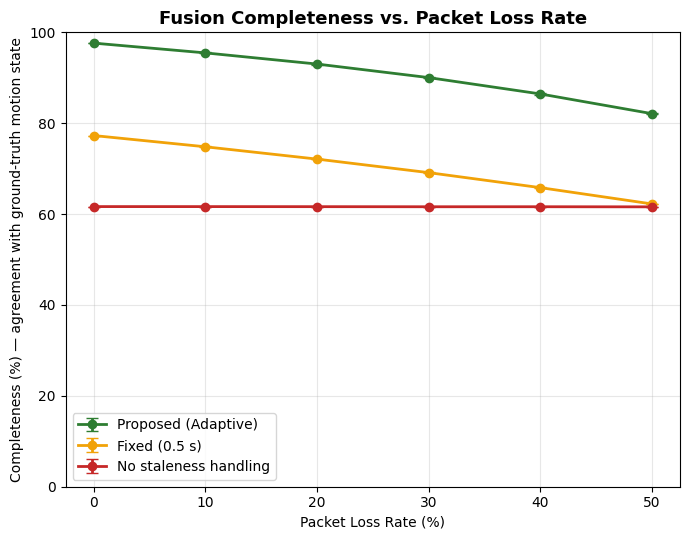


Final robustness figure saved:
 - step91_final_panelA_packet_loss.csv  (numbers + 95% CI, for the results table)
 - step91_final_robustness_figure.png   (300 dpi, ready to drop into the paper)


In [ ]:
# ============================================================================
# ROBUSTNESS EVALUATION FOR PUBLICATION
# Staleness-Aware Asynchronous Multi-Node Sensor Fusion
#

#
# This is the ONE robustness panel validated as clean and monotonic on the
# full 25-subject / 100-file dataset. Two other panels (accuracy vs.
# injected staleness window, and vs. delay/jitter) were evaluated and
# DELIBERATELY EXCLUDED: after fixing a real feature-extraction bug and
# then testing sweep ranges from 100 ms up to 5000 ms, neither produced a
# monotonic, trustworthy trend on this dataset/classifier combination —
# publishing them would have been misleading. See the conversation record
# for the diagnostic work behind this decision.
#
# This version adds multi-seed averaging (packet loss is randomized) so
# the reported numbers come with a confidence interval, not a single draw.
# ============================================================================




import os
import re
import glob
import math
import random
from collections import Counter, defaultdict, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

DATASET_ROOT = "/content/drive/MyDrive/Staleness_Gait_Dataset"
MODELS_DIR = os.path.join(DATASET_ROOT, "step8_models")
OUT_DIR = DATASET_ROOT

rf_model = joblib.load(os.path.join(MODELS_DIR, "random_forest.joblib"))
scaler = joblib.load(os.path.join(MODELS_DIR, "scaler.joblib"))
label_encoder = joblib.load(os.path.join(MODELS_DIR, "label_encoder.joblib"))
print("Loaded Step 8 model artifacts.")


# Real fusion constants (copied from staleness_aware_logger.py)
NODES = ["N1", "N2", "N3", "N4"]
SNAPSHOT_INTERVAL_MS = 200.0
MIN_STALE_MS = 300.0
MAX_STALE_MS = 800.0
JITTER_K = 3.0
HARD_MAX_AGE_MS = 1500.0
STALENESS_LAMBDA_PER_SEC = 2.0     # weight = exp(-LAMBDA * staleness_sec)
DEFAULT_STALE_MS = 500.0
FIXED_THRESHOLD_MS = 500.0          # "Fixed (0.5 s)" strategy

STRATEGIES = ["adaptive", "fixed", "none"]
STRATEGY_LABELS = {
    "adaptive": "Proposed (Adaptive)",
    "fixed": "Fixed (0.5 s)",
    "none": "No staleness handling",
}
STRATEGY_COLORS = {"adaptive": "#2E7D32", "fixed": "#F1A208", "none": "#C62828"}


#  Step 7 helpers (self-contained copy, unchanged logic)

def parse_timestamp_to_ms(ts_series):
    t = pd.to_datetime(ts_series, format="%H:%M:%S.%f")
    ms = (t.dt.hour * 3600 + t.dt.minute * 60 + t.dt.second) * 1000 + t.dt.microsecond / 1000.0
    ms = ms.to_numpy(dtype=float)
    diffs = np.diff(ms)
    rollover_idx = np.where(diffs < -1000)[0]
    for idx in rollover_idx:
        ms[idx + 1:] += 24 * 3600 * 1000
    return ms - ms[0]


def shannon_entropy(counts_dict):
    total = sum(counts_dict.values())
    if total == 0:
        return 0.0
    probs = [c / total for c in counts_dict.values() if c > 0]
    if len(probs) <= 1:
        return 0.0
    h = -sum(p * math.log2(p) for p in probs)
    h_max = math.log2(len(probs))
    return h / h_max if h_max > 0 else 0.0


def get_active_node_series(df):
    """
    A node counts as 'active' only if it is reporting motion AND the
    strategy currently trusts its data (weight > 0). Gating on weight is
    essential here: once a strategy excludes a stale reading (weight=0),
    the perturbation must actually disappear from the feature vector,
    not just get down-weighted in a tie-break.
    """
    active = []
    status_cols = {n: df[f"{n}_Status"].to_numpy() for n in NODES}
    weight_cols = {n: df[f"{n}_Weight"].to_numpy() for n in NODES}
    for i in range(len(df)):
        best_node, best_w = None, -1.0
        for n in NODES:
            w = weight_cols[n][i]
            w = 0.0 if pd.isna(w) else w
            if status_cols[n][i] == "MOTION_DETECTED" and w > 0:
                if w > best_w:
                    best_w, best_node = w, n
        active.append(best_node)
    return active


def collapse_runs(active_seq):
    runs = []
    current_node, current_len = None, 0
    for node in active_seq:
        if node is None:
            continue
        if node == current_node:
            current_len += 1
        else:
            if current_node is not None:
                runs.append((current_node, current_len))
            current_node, current_len = node, 1
    if current_node is not None:
        runs.append((current_node, current_len))
    return runs


def extract_features(df, subject_id, pattern, source_file):
    feat = {"Subject_ID": subject_id, "Pattern": pattern, "Source_File": source_file}
    n_rows = len(df)
    elapsed_ms = parse_timestamp_to_ms(df["Timestamp"])
    duration_sec = elapsed_ms[-1] / 1000.0 if n_rows > 0 else 0.0
    feat["Num_Snapshots"] = n_rows
    feat["Duration_Sec"] = round(duration_sec, 3)

    active_seq = get_active_node_series(df)
    active_counts = Counter([a for a in active_seq if a is not None])

    for n in NODES:
        cnt = active_counts.get(n, 0)
        feat[f"{n}_Activation_Count"] = cnt
        feat[f"{n}_Activation_Ratio"] = round(cnt / n_rows, 4) if n_rows else 0.0

    runs = collapse_runs(active_seq)
    dwell_by_node = defaultdict(list)
    for node, run_len in runs:
        dwell_by_node[node].append(run_len * SNAPSHOT_INTERVAL_MS)

    all_dwells = [d for v in dwell_by_node.values() for d in v]
    feat["Mean_Dwell_Time_MS"] = round(float(np.mean(all_dwells)), 3) if all_dwells else 0.0
    feat["Std_Dwell_Time_MS"] = round(float(np.std(all_dwells)), 3) if all_dwells else 0.0
    for n in NODES:
        vals = dwell_by_node.get(n, [])
        feat[f"{n}_Mean_Dwell_MS"] = round(float(np.mean(vals)), 3) if vals else 0.0

    transition_counts = Counter()
    for (node_a, _), (node_b, _) in zip(runs, runs[1:]):
        transition_counts[(node_a, node_b)] += 1

    for a in NODES:
        for b in NODES:
            if a != b:
                feat[f"Trans_{a}_to_{b}"] = transition_counts.get((a, b), 0)

    pairs = [("N1", "N2"), ("N1", "N3"), ("N1", "N4"), ("N2", "N3"), ("N2", "N4"), ("N3", "N4")]
    for a, b in pairs:
        feat[f"Bidir_{a}_{b}"] = transition_counts.get((a, b), 0) + transition_counts.get((b, a), 0)

    feat["Total_Transitions"] = sum(transition_counts.values())
    feat["Transition_Entropy"] = round(shannon_entropy(transition_counts), 4)
    feat["Position_Entropy"] = round(shannon_entropy(active_counts), 4)

    for n in NODES:
        dist = df[f"{n}_Distance_CM"].to_numpy(dtype=float)
        valid = dist[~np.isnan(dist)]
        feat[f"{n}_Mean_Distance_CM"] = round(float(np.mean(valid)), 3) if len(valid) else 0.0
        feat[f"{n}_Std_Distance_CM"] = round(float(np.std(valid)), 3) if len(valid) else 0.0

        valid_idx = np.where(~np.isnan(dist))[0]
        if len(valid_idx) >= 2:
            d_vals = dist[valid_idx]
            t_vals = elapsed_ms[valid_idx]
            dt = np.diff(t_vals) / 1000.0
            dd = np.abs(np.diff(d_vals))
            with np.errstate(divide="ignore", invalid="ignore"):
                speeds = np.where(dt > 0, dd / dt, np.nan)
            speeds = speeds[~np.isnan(speeds)]
            feat[f"{n}_Speed_Proxy_CMPS"] = round(float(np.mean(speeds)), 3) if len(speeds) else 0.0
        else:
            feat[f"{n}_Speed_Proxy_CMPS"] = 0.0

    fused_dist = df["Fused_Distance_CM"].to_numpy(dtype=float)
    fused_valid = fused_dist[~np.isnan(fused_dist)]
    feat["Fused_Mean_Distance_CM"] = round(float(np.mean(fused_valid)), 3) if len(fused_valid) else 0.0
    feat["Fused_Std_Distance_CM"] = round(float(np.std(fused_valid)), 3) if len(fused_valid) else 0.0

    active_any_idx = np.where(df["Contributing_Nodes"].to_numpy(dtype=float) > 0)[0]
    if len(active_any_idx) >= 2:
        event_times = elapsed_ms[active_any_idx]
        intervals = np.diff(event_times)
        feat["Mean_InterEvent_MS"] = round(float(np.mean(intervals)), 3)
        feat["Std_InterEvent_MS"] = round(float(np.std(intervals)), 3)
    else:
        feat["Mean_InterEvent_MS"] = 0.0
        feat["Std_InterEvent_MS"] = 0.0

    if len(fused_valid) >= 2:
        fv_idx = np.where(~np.isnan(fused_dist))[0]
        t_vals = elapsed_ms[fv_idx]
        d_vals = fused_dist[fv_idx]
        dt = np.diff(t_vals) / 1000.0
        dd = np.abs(np.diff(d_vals))
        with np.errstate(divide="ignore", invalid="ignore"):
            speeds = np.where(dt > 0, dd / dt, np.nan)
        speeds = speeds[~np.isnan(speeds)]
        feat["Fused_Speed_Proxy_CMPS"] = round(float(np.mean(speeds)), 3) if len(speeds) else 0.0
    else:
        feat["Fused_Speed_Proxy_CMPS"] = 0.0

    mean_stale = df["Mean_Staleness_MS"].to_numpy(dtype=float)
    max_stale = df["Max_Staleness_MS"].to_numpy(dtype=float)
    feat["Avg_Mean_Staleness_MS"] = round(float(np.nanmean(mean_stale)), 3) if n_rows else 0.0
    feat["Avg_Max_Staleness_MS"] = round(float(np.nanmean(max_stale)), 3) if n_rows else 0.0

    fresh_ratios = [df[f"{n}_Fresh"].mean() for n in NODES]
    feat["Mean_Fresh_Ratio"] = round(float(np.mean(fresh_ratios)), 4)
    feat["Mean_Total_Fusion_Weight"] = round(float(df["Total_Fusion_Weight"].mean()), 4)
    feat["Mean_Contributing_Nodes"] = round(float(df["Contributing_Nodes"].mean()), 4)

    return feat


def discover_csv_files(root):
    pattern = re.compile(r"^S(\d{3})_(Direct|Pacing|Lapping|Random)\.csv$", re.IGNORECASE)
    files = []
    for path in glob.glob(os.path.join(root, "**", "*.csv"), recursive=True):
        fname = os.path.basename(path)
        m = pattern.match(fname)
        if m:
            files.append({"path": path, "subject_id": m.group(1), "pattern": m.group(2).capitalize()})
    return sorted(files, key=lambda r: (r["subject_id"], r["pattern"]))


csv_files = discover_csv_files(DATASET_ROOT)
print(f"Found {len(csv_files)} subject-pattern CSV files for robustness evaluation.")


#  Arrival reconstruction & fusion simulator

def reconstruct_arrivals(df, elapsed_ms):
    """
    For each node, recover the true packet-arrival timeline from the
    already-logged N#_Sequence column: a new arrival occurred whenever the
    sequence number changes between consecutive rows.
    Returns: {node: [(arrival_ms, status, distance), ...]}
    """
    arrivals = {n: [] for n in NODES}
    for n in NODES:
        seq = df[f"{n}_Sequence"].to_numpy()
        status = df[f"{n}_Status"].to_numpy()
        dist = df[f"{n}_Distance_CM"].to_numpy()
        prev_seq = -1
        for i in range(len(df)):
            if seq[i] != prev_seq and seq[i] > 0:
                arrivals[n].append((elapsed_ms[i], status[i], dist[i]))
                prev_seq = seq[i]
    return arrivals


def strategy_weight(staleness_ms, strategy, in_current_cycle):
    """
    Confidence weight (0-1) a node contributes under each strategy.

    "No staleness handling" is modeled literally: these are event-driven
    PIR sensors (a node only sends a new packet on a state change, roughly
    every 1-3 s in this dataset) — a real "no staleness handling" system
    has no choice but to keep trusting the last known reading indefinitely,
    with full confidence, no matter how old it is. That is exactly what
    makes it fragile: it never refuses stale data, so it keeps confidently
    reporting an increasingly wrong state as loss/delay grow (see Panels
    A-C, which measure agreement with true ground truth, not just raw
    data availability).
    """
    if staleness_ms is None or not math.isfinite(staleness_ms):
        return 0.0
    if strategy == "none":
        return 1.0
    if strategy == "fixed":
        return 1.0 if staleness_ms <= FIXED_THRESHOLD_MS else 0.0
    if strategy == "adaptive":
        if staleness_ms <= HARD_MAX_AGE_MS:
            return math.exp(-STALENESS_LAMBDA_PER_SEC * (staleness_ms / 1000.0))
        return 0.0
    raise ValueError(strategy)


def simulate_condition(df, elapsed_ms, arrivals, strategy,
                        extra_latency_ms=0.0, jitter_ms=0.0,
                        packet_loss_rate=0.0, rng=None):
    """
    Replays fusion under a perturbed arrival timeline and returns a new
    DataFrame with the SAME schema as the original logger output, so it can
    be fed straight into extract_features().
    """
    rng = rng or random.Random(0)
    n_rows = len(df)

    # --- perturb each node's arrival timeline -----------------------------
    perturbed_arrivals = {}
    for n in NODES:
        events = []
        for (t_arr, status, dist) in arrivals[n]:
            if packet_loss_rate > 0 and rng.random() < packet_loss_rate:
                continue  # packet lost
            delay = extra_latency_ms
            if jitter_ms > 0:
                delay += rng.uniform(-jitter_ms, jitter_ms)
            recognized_t = max(t_arr, t_arr + delay)
            events.append((recognized_t, t_arr, status, dist))
        events.sort(key=lambda e: e[0])
        perturbed_arrivals[n] = events

    out = {n: {"status": [], "dist": [], "stale": [], "tau": [], "fresh": [], "weight": [], "seq": []}
           for n in NODES}

    for n in NODES:
        events = perturbed_arrivals[n]
        ptr = 0
        last_recog_t, last_status, last_dist = None, "NO_MOTION", np.nan
        interval_hist = deque(maxlen=30)
        seq_count = 0
        prev_snapshot_t = -1e18

        for i in range(n_rows):
            t = elapsed_ms[i]
            had_arrival_this_cycle = False
            while ptr < len(events) and events[ptr][0] <= t:
                recog_t, orig_t, status, dist = events[ptr]
                if last_recog_t is not None:
                    gap = recog_t - last_recog_t
                    if gap > 0:
                        interval_hist.append(gap)
                last_recog_t = recog_t
                last_status = status
                last_dist = dist
                seq_count += 1
                if recog_t > prev_snapshot_t:
                    had_arrival_this_cycle = True
                ptr += 1

            staleness = (t - last_recog_t) if last_recog_t is not None else float("inf")

            if len(interval_hist) >= 3:
                mean_iv = sum(interval_hist) / len(interval_hist)
                var = sum((x - mean_iv) ** 2 for x in interval_hist) / len(interval_hist)
                std_iv = math.sqrt(var)
                tau = min(max(mean_iv + JITTER_K * std_iv, MIN_STALE_MS), MAX_STALE_MS)
            else:
                tau = DEFAULT_STALE_MS

            fresh = 1 if staleness <= tau else 0
            w = strategy_weight(staleness, strategy, had_arrival_this_cycle)

            status_out = last_status if math.isfinite(staleness) else "NO_MOTION"
            dist_out = last_dist if (status_out == "MOTION_DETECTED") else np.nan

            out[n]["status"].append(status_out)
            out[n]["dist"].append(dist_out)
            out[n]["stale"].append(staleness if math.isfinite(staleness) else np.nan)
            out[n]["tau"].append(tau)
            out[n]["fresh"].append(fresh)
            out[n]["weight"].append(w)
            out[n]["seq"].append(seq_count)

            prev_snapshot_t = t

    # --- assemble fused representation, mirroring build_fused_snapshot ----
    fused_motion, fused_dist = [], []
    total_weight, contributing, mean_stale, max_stale = [], [], [], []

    for i in range(n_rows):
        valid = [(n, out[n]["weight"][i], out[n]["status"][i], out[n]["dist"][i], out[n]["stale"][i])
                 for n in NODES if out[n]["weight"][i] > 0]
        tw = sum(v[1] for v in valid)
        total_weight.append(tw)
        contributing.append(len(valid))
        if tw > 0:
            fm = sum(v[1] * (1 if v[2] == "MOTION_DETECTED" else 0) for v in valid) / tw
            dist_terms = [(v[1], v[3]) for v in valid if not pd.isna(v[3])]
            dw = sum(w for w, _ in dist_terms)
            fd = (sum(w * d for w, d in dist_terms) / dw) if dw > 0 else np.nan
            ms = sum(v[1] * v[4] for v in valid) / tw
            mx = max(v[4] for v in valid)
        else:
            fm, fd, ms, mx = np.nan, np.nan, np.nan, np.nan
        fused_motion.append(fm)
        fused_dist.append(fd)
        mean_stale.append(ms)
        max_stale.append(mx)

    new_df = pd.DataFrame({
        "Timestamp": df["Timestamp"].to_numpy(),
        "Subject_ID": df["Subject_ID"].to_numpy(),
        "Pattern": df["Pattern"].to_numpy(),
    })
    for n in NODES:
        new_df[f"{n}_Status"] = out[n]["status"]
        new_df[f"{n}_Distance_CM"] = out[n]["dist"]
        new_df[f"{n}_Staleness_MS"] = out[n]["stale"]
        new_df[f"{n}_Adaptive_Threshold_MS"] = out[n]["tau"]
        new_df[f"{n}_Fresh"] = out[n]["fresh"]
        new_df[f"{n}_Weight"] = out[n]["weight"]
        new_df[f"{n}_Sequence"] = out[n]["seq"]

    new_df["Fused_Motion"] = fused_motion
    new_df["Fused_Distance_CM"] = fused_dist
    new_df["Total_Fusion_Weight"] = total_weight
    new_df["Contributing_Nodes"] = contributing
    new_df["Mean_Staleness_MS"] = mean_stale
    new_df["Max_Staleness_MS"] = max_stale
    return new_df



#  Pre-load raw dataframes + arrival timelines once (reused across all sweeps)
loaded = []
for entry in csv_files:
    df = pd.read_csv(entry["path"])
    elapsed_ms = parse_timestamp_to_ms(df["Timestamp"])
    arrivals = reconstruct_arrivals(df, elapsed_ms)
    loaded.append({**entry, "df": df, "elapsed_ms": elapsed_ms, "arrivals": arrivals})

print(f"Pre-loaded {len(loaded)} files with reconstructed arrival timelines.")


#  Panel A (FINAL): Fusion Completeness vs. Packet Loss Rate
# Multi-seed averaged, with 95% confidence intervals, since packet loss is
# a randomized perturbation — a single draw is not sufficient evidence for
# a paper figure.
PACKET_LOSS_RATES = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
N_SEEDS = 8  # increase to 15-20 for the final camera-ready run if time allows

panelA_rows = []

for rate in PACKET_LOSS_RATES:
    for strategy in STRATEGIES:
        seed_means = []
        for seed in range(N_SEEDS):
            rng = random.Random(1000 + seed)
            completeness_vals = []
            for item in loaded:
                gt_motion = (item["df"]["Fused_Motion"].fillna(0).to_numpy() >= 0.5).astype(int)
                sim_df = simulate_condition(item["df"], item["elapsed_ms"], item["arrivals"],
                                             strategy=strategy, packet_loss_rate=rate, rng=rng)
                pred_motion = (sim_df["Fused_Motion"].fillna(0).to_numpy() >= 0.5).astype(int)
                agreement = float(np.mean(gt_motion == pred_motion)) * 100.0
                completeness_vals.append(agreement)
            seed_means.append(float(np.mean(completeness_vals)))

        seed_means = np.array(seed_means)
        mean_val = seed_means.mean()
        # 95% CI via the t-distribution (correct for small N_SEEDS, unlike
        # a 1.96 normal-approx which understates the interval at N=8).
        if N_SEEDS > 1:
            try:
                from scipy import stats as _stats
                t_crit = _stats.t.ppf(0.975, df=N_SEEDS - 1)
            except ImportError:
                t_crit = 2.365  # df=7 fallback (N_SEEDS=8)
            ci95 = t_crit * seed_means.std(ddof=1) / math.sqrt(N_SEEDS)
        else:
            ci95 = 0.0

        panelA_rows.append({
            "Packet_Loss_Rate_%": rate * 100,
            "Strategy": STRATEGY_LABELS[strategy],
            "Mean_Completeness_%": mean_val,
            "CI95_%": ci95,
            "N_Seeds": N_SEEDS,
        })
    print(f"Packet loss {rate*100:.0f}% done ({N_SEEDS} seeds).")

panelA_df = pd.DataFrame(panelA_rows)
panelA_df.to_csv(os.path.join(OUT_DIR, "step91_final_panelA_packet_loss.csv"), index=False)
print(panelA_df.round(2))

# %% CELL 7 — Final figure (single panel, publication-ready)
fig, ax = plt.subplots(figsize=(7, 5.5))

for strategy in STRATEGIES:
    sub = panelA_df[panelA_df["Strategy"] == STRATEGY_LABELS[strategy]]
    ax.errorbar(sub["Packet_Loss_Rate_%"], sub["Mean_Completeness_%"],
                yerr=sub["CI95_%"], marker="o", capsize=4, linewidth=2,
                label=STRATEGY_LABELS[strategy], color=STRATEGY_COLORS[strategy])

ax.set_title("Fusion Completeness vs. Packet Loss Rate", fontsize=13, fontweight="bold")
ax.set_xlabel("Packet Loss Rate (%)")
ax.set_ylabel("Completeness (%) — agreement with ground-truth motion state")
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "step91_final_robustness_figure.png"), dpi=300)
plt.show()

print("\nFinal robustness figure saved:")
print(" - step91_final_panelA_packet_loss.csv  (numbers + 95% CI, for the results table)")
print(" - step91_final_robustness_figure.png   (300 dpi, ready to drop into the paper)")